#  PPE Detection — YOLOv8 Fine-Tuning
**CSCI435 Computer Vision Project**

This notebook covers:
1. Environment setup
2. Kaggle dataset download
3. Dataset inspection & YAML config generation
4. YOLOv8 fine-tuning
5. Evaluation & metrics
6. Inference script (image, video, webcam)

> ️ Make sure GPU is enabled: Runtime → Change runtime type → T4 GPU

##  Step 1 — Check GPU

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU — go to Runtime > Change runtime type > T4 GPU')
!nvidia-smi

CUDA available: True
Device: Tesla T4
Sun Jun  7 10:49:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------

##  Step 2 — Install Dependencies

In [2]:
!pip install ultralytics kaggle -q
from ultralytics import YOLO
import os, yaml, shutil
from pathlib import Path
print('Ultralytics version:', __import__('ultralytics').__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.61


## Step 4 — Dataset Upload

Upload the downloaded dataset zip file when prompted.

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"hoor786","key":"KGAT_4a623f5c484ec61e2f6625f52629abf9"}')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install kaggle -q
!kaggle datasets download -d shlokraval/ppe-dataset-yolov8 -p /content/ppe_raw --unzip
print('Done')


Dataset URL: https://www.kaggle.com/datasets/shlokraval/ppe-dataset-yolov8
License(s): apache-2.0
100% 2.35G/2.35G [00:28<00:00, 90.1MB/s]

Done


##  Step 5 — Inspect Dataset & Auto-Detect Classes

In [4]:
from pathlib import Path

raw = Path('/content/ppe_raw')

# Find existing YAML if present
yaml_files = list(raw.rglob('*.yaml')) + list(raw.rglob('*.yml'))
print('YAML files found:', yaml_files)

if yaml_files:
    with open(yaml_files[0]) as f:
        existing = yaml.safe_load(f)
    print('\nExisting YAML contents:')
    print(existing)
    CLASSES = existing.get('names', [])
    print('\nClasses detected from YAML:', CLASSES)
else:
    print('No YAML found — will infer classes from label files')
    CLASSES = None

# Count images
images = list(raw.rglob('*.jpg')) + list(raw.rglob('*.png')) + list(raw.rglob('*.jpeg'))
labels = list(raw.rglob('*.txt'))
print(f'\nTotal images: {len(images)}')
print(f'Total label files: {len(labels)}')

YAML files found: [PosixPath('/content/ppe_raw/data.yaml')]

Existing YAML contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 14, 'names': ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest'], 'roboflow': {'workspace': 'roboflow-universe-projects', 'project': 'personal-protective-equipment-combined-model', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/roboflow-universe-projects/personal-protective-equipment-combined-model/dataset/4'}}

Classes detected from YAML: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']

Total images: 44002
Total label files: 44004


##  Step 6 — Organise Dataset into YOLO Structure

YOLO expects:
```
dataset/
  images/train/
  images/val/
  labels/train/
  labels/val/
```

In [5]:
import random
from pathlib import Path
import shutil

DATASET_DIR = Path('/content/ppe_dataset')
for split in ['train', 'val']:
    (DATASET_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

raw = Path('/content/ppe_raw')

# Copy train
for img in (raw / 'train' / 'images').iterdir():
    if img.suffix in ['.jpg', '.png', '.jpeg']:
        shutil.copy(img, DATASET_DIR / 'images' / 'train' / img.name)
for lbl in (raw / 'train' / 'labels').iterdir():
    if lbl.suffix == '.txt':
        shutil.copy(lbl, DATASET_DIR / 'labels' / 'train' / lbl.name)

# Copy val (folder is named 'valid' in this dataset)
for img in (raw / 'valid' / 'images').iterdir():
    if img.suffix in ['.jpg', '.png', '.jpeg']:
        shutil.copy(img, DATASET_DIR / 'images' / 'val' / img.name)
for lbl in (raw / 'valid' / 'labels').iterdir():
    if lbl.suffix == '.txt':
        shutil.copy(lbl, DATASET_DIR / 'labels' / 'val' / lbl.name)

train_count = len(list((DATASET_DIR / 'images' / 'train').iterdir()))
val_count = len(list((DATASET_DIR / 'images' / 'val').iterdir()))
print(f'Train images: {train_count}')
print(f'Val images:   {val_count}')
print('Dataset organised')

Train images: 30765
Val images:   8814
Dataset organised


##  Step 7 — Create dataset.yaml

In [6]:
CLASS_NAMES = [
    'Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask',
    'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
    'Person', 'Safety Cone', 'Safety Vest'
]
# 14 classes from Roboflow PPE Combined Model dataset

dataset_yaml = {
    'path': str(DATASET_DIR),
    'train': 'images/train',
    'val':   'images/val',
    'nc':    14,
    'names': CLASS_NAMES
}

yaml_path = '/content/ppe_dataset.yaml'
import yaml
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('dataset.yaml created')
print(f'Classes (14):', CLASS_NAMES)


dataset.yaml created
Classes (14): ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


##  Step 8 — Fine-Tune YOLOv8

In [7]:
from ultralytics import YOLO

# Mount Google Drive — weights persist across disconnects
from google.colab import drive
drive.mount('/content/drive')

# Load base YOLOv8s weights
model = YOLO('yolov8s.pt')

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    name='ppe_v3',
    project='/content/drive/MyDrive/ppe_runs',  # saves to Drive — disconnect-safe
    patience=20,
    save=True,
    plots=True,
    verbose=True,
    device=0,
    hsv_h=0.015,
    hsv_s=0.9,      # strong colour augmentation — handles vest colour variation
    hsv_v=0.5,      # strong brightness augmentation
    fliplr=0.5,
    flipud=0.1,
    mosaic=1.0,
    scale=0.5,
    translate=0.1,
)

print("Training complete")
print("Weights saved to Google Drive at: MyDrive/ppe_runs/ppe_v3/weights/best.pt")


Mounted at /content/drive
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.9, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

##  Step 9 — Evaluate Model

In [9]:
from ultralytics import YOLO
import glob

weight_paths = glob.glob('/content/drive/MyDrive/ppe_runs/ppe_v3/weights/best.pt')
if not weight_paths:
    weight_paths = glob.glob('/content/drive/MyDrive/ppe_runs/**/weights/best.pt', recursive=True)
if not weight_paths:
    weight_paths = glob.glob('/content/runs/**/weights/best.pt', recursive=True)

best_weights = weight_paths[0]
print('Using weights:', best_weights)

model = YOLO(best_weights)
metrics = model.val(data=yaml_path, imgsz=640)

print('========== EVALUATION RESULTS ==========')
print(f'mAP50:       {metrics.box.map50:.4f}')
print(f'mAP50-95:    {metrics.box.map:.4f}')
print(f'Precision:   {metrics.box.mp:.4f}')
print(f'Recall:      {metrics.box.mr:.4f}')
print('========================================')
print('Per-class AP50:')
for i, name in enumerate(CLASS_NAMES):
    if i < len(metrics.box.ap50):
        print(f'  {name}: {metrics.box.ap50[i]:.4f}')


Using weights: /content/drive/MyDrive/ppe_runs/ppe_v3/weights/best.pt
Ultralytics 8.4.61 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 956.7±288.6 MB/s, size: 50.6 KB)
val: Scanning /content/ppe_dataset/labels/val.cache... 8814 images, 210 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8814/8814 2.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 551/551 4.4it/s 2:06
                   all       8814      22077      0.714      0.815      0.774      0.501
         Fall-Detected        899        899      0.722      0.823      0.847      0.565
                Gloves        395        858       0.83      0.936      0.944      0.496
               Goggles        746        827      0.824      0.973      0.961      0.582
               Hardhat       3191       8952      0.819    

##  Step 10 — Visualise Training Curves

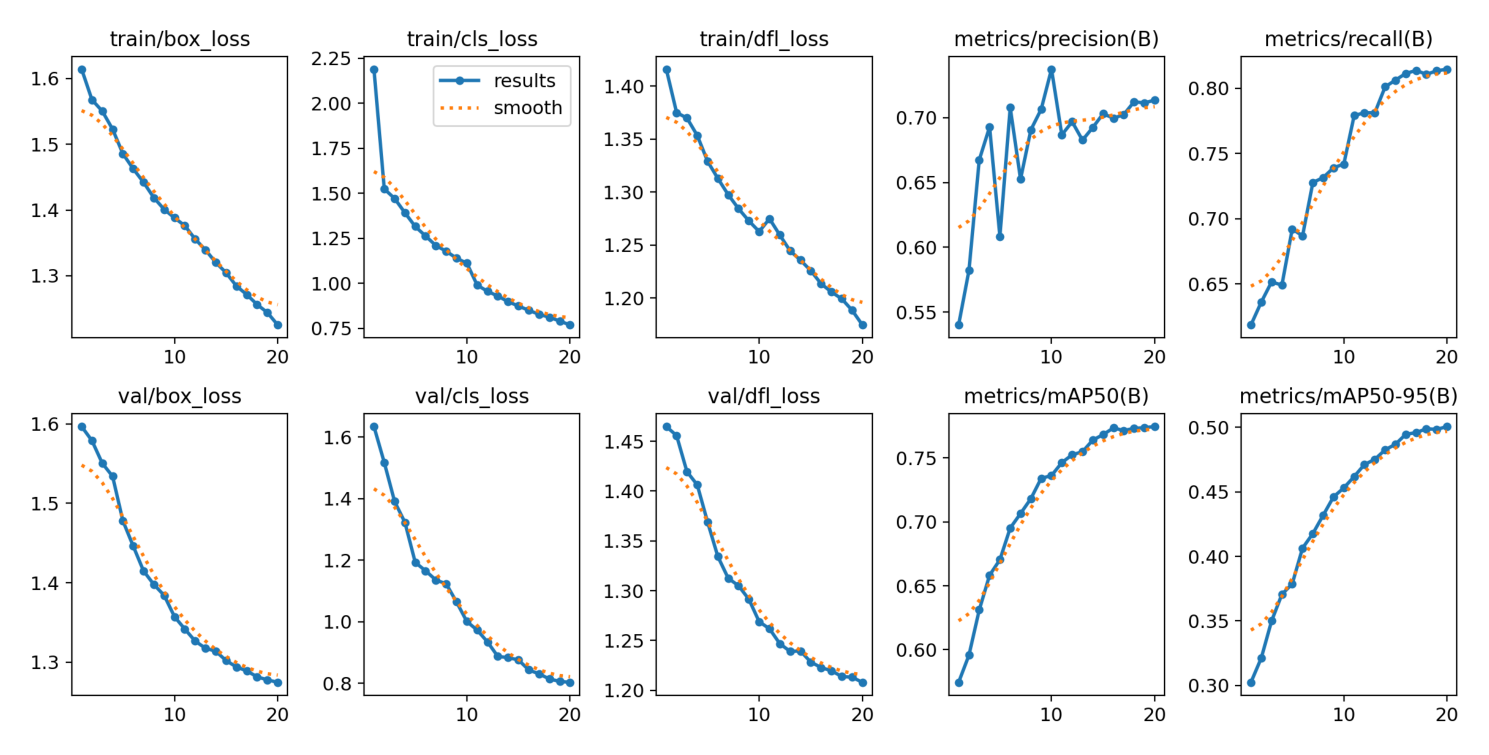

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import os

run_dir = '/content/drive/MyDrive/ppe_runs/ppe_v3'
img = Image.open(f'{run_dir}/results.png')
fig, ax = plt.subplots(figsize=(15, 9))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

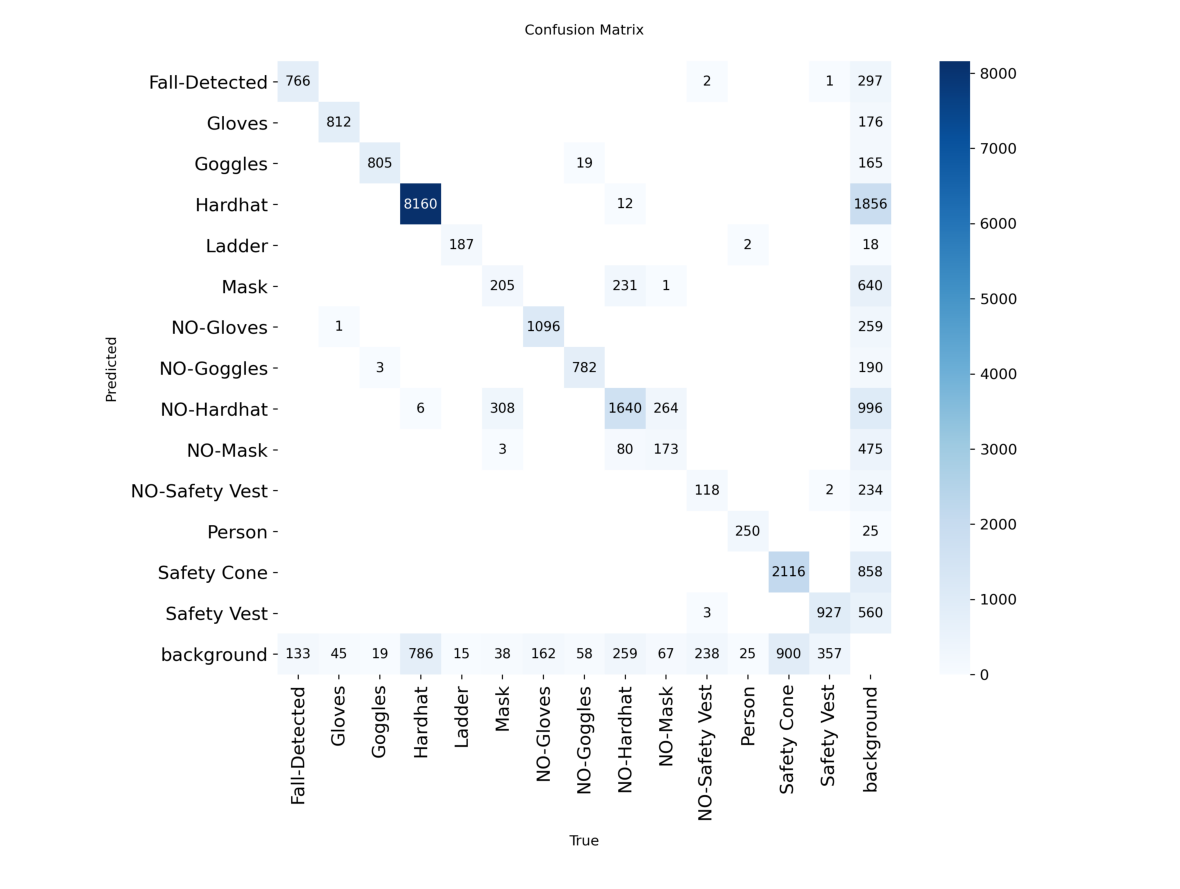

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import os

run_dir = '/content/drive/MyDrive/ppe_runs/ppe_v3'
img = Image.open(f'{run_dir}/confusion_matrix.png')
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

##  Step 11 — Inference Script (Image + Video + Webcam)

In [16]:
CLASS_NAMES = [
    'Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask',
    'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest',
    'Person', 'Safety Cone', 'Safety Vest'
]
# 14 classes from Roboflow PPE Combined Model dataset

dataset_yaml = {
    'path': str(DATASET_DIR),
    'train': 'images/train',
    'val':   'images/val',
    'nc':    14,
    'names': CLASS_NAMES
}

yaml_path = '/content/ppe_dataset.yaml'
import yaml
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('dataset.yaml created')
print(f'Classes (14):', CLASS_NAMES)


dataset.yaml created
Classes (14): ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


##  Step 12 — Quick Test (on val images)


image 1/1 /content/ppe_dataset/images/val/people-3658-_jpg.rf.999081ac02a3ad87d248576e85d15008.jpg: 640x640 1 Fall-Detected, 16.2ms
Speed: 3.3ms preprocess, 16.2ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 640)

Input: people-3658-_jpg.rf.999081ac02a3ad87d248576e85d15008.jpg


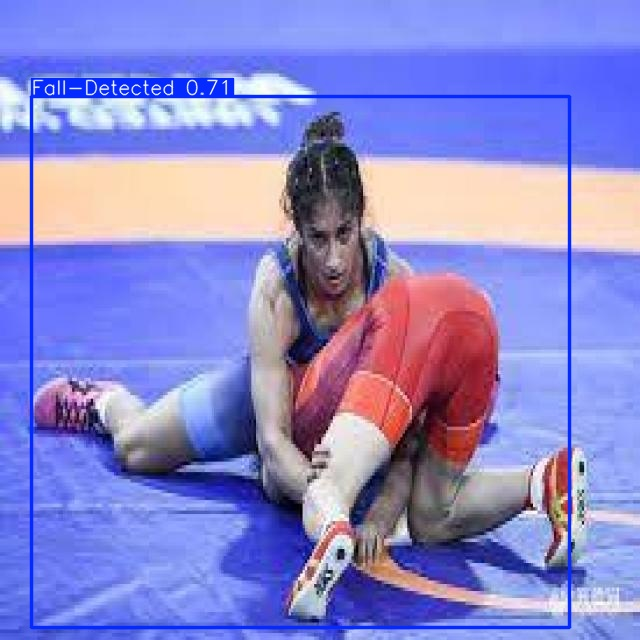


image 1/1 /content/ppe_dataset/images/val/-279-_png_jpg.rf.70dda767ba0ac3affc029c15e47d5aec.jpg: 640x640 1 Hardhat, 16.2ms
Speed: 2.0ms preprocess, 16.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

Input: -279-_png_jpg.rf.70dda767ba0ac3affc029c15e47d5aec.jpg


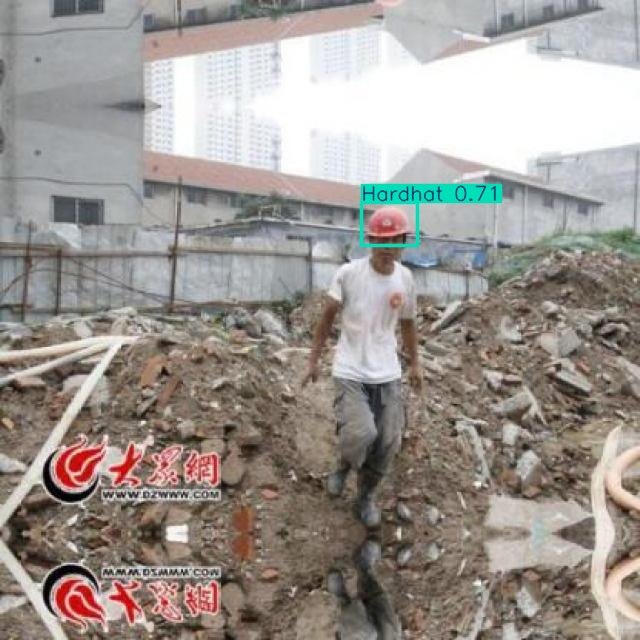


image 1/1 /content/ppe_dataset/images/val/kp1585_jpg.rf.c86e4ca08521e33a843c74102b8704f2.jpg: 640x640 2 NO-Goggless, 16.2ms
Speed: 1.6ms preprocess, 16.2ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)

Input: kp1585_jpg.rf.c86e4ca08521e33a843c74102b8704f2.jpg


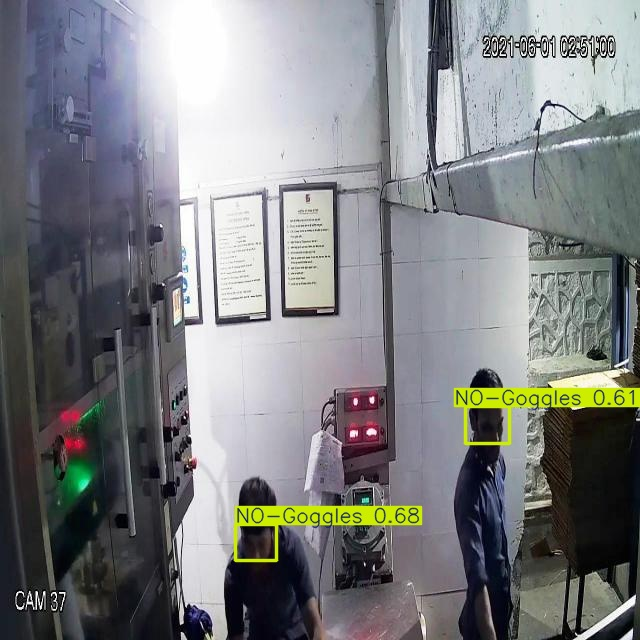

In [17]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob, random, shutil

model = YOLO(best_weights)

# Pick 3 random val images
val_imgs = list((DATASET_DIR / 'images' / 'val').iterdir())
samples = random.sample(val_imgs, min(3, len(val_imgs)))

for img_path in samples:
    results = model(str(img_path))
    results[0].save(filename='/content/sample_output.jpg')
    print(f'\nInput: {img_path.name}')
    display(Image('/content/sample_output.jpg'))

##  Step 13 — Download Your Deliverables

In [19]:
inference_script = '''
import cv2
import torch
from ultralytics import YOLO
from pathlib import Path

WEIGHTS_PATH = "best.pt"
CONF_THRESHOLD = 0.35
IOU_THRESHOLD = 0.45

CLASS_COLORS = {
    "Hardhat":        (0, 255, 0),
    "NO-Hardhat":     (0, 0, 255),
    "Safety Vest":    (0, 255, 128),
    "NO-Safety Vest": (0, 0, 200),
    "Mask":           (255, 165, 0),
    "NO-Mask":        (0, 100, 255),
    "Gloves":         (255, 200, 0),
    "NO-Gloves":      (0, 80, 255),
    "Goggles":        (200, 100, 255),
    "NO-Goggles":     (100, 0, 200),
    "Person":         (200, 200, 200),
    "Safety Cone":    (0, 165, 255),
    "Ladder":         (150, 150, 0),
    "Fall-Detected":  (0, 0, 255),
}
DEFAULT_COLOR = (255, 255, 0)

model = YOLO(WEIGHTS_PATH)
model.conf = CONF_THRESHOLD
model.iou  = IOU_THRESHOLD
CLASS_NAMES = model.names


def draw_results(frame, results):
    detected = []
    for r in results:
        for box in r.boxes:
            cls_id   = int(box.cls[0])
            cls_name = CLASS_NAMES[cls_id]
            conf     = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            color = CLASS_COLORS.get(cls_name, DEFAULT_COLOR)
            label = f"{cls_name} {conf:.2f}"
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
            detected.append(cls_name)
    non_compliant = [d for d in detected if d.startswith("NO-") or d == "Fall-Detected"]
    if non_compliant:
        status = f"NON-COMPLIANT: {', '.join(set(non_compliant))}"
        cv2.rectangle(frame, (0, 0), (frame.shape[1], 40), (0, 0, 200), -1)
        cv2.putText(frame, status, (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
    elif detected:
        cv2.rectangle(frame, (0, 0), (frame.shape[1], 40), (0, 180, 0), -1)
        cv2.putText(frame, "COMPLIANT", (10, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2)
    return frame


def run_on_image(image_path, output_path=None):
    frame = cv2.imread(str(image_path))
    results = model(frame)
    frame = draw_results(frame, results)
    if output_path:
        cv2.imwrite(str(output_path), frame)
    return frame


def run_on_video(video_path, output_path=None):
    cap = cv2.VideoCapture(str(video_path))
    fps = int(cap.get(cv2.CAP_PROP_FPS)) or 25
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = None
    if output_path:
        writer = cv2.VideoWriter(str(output_path),
                                 cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        results = model(frame, verbose=False)
        frame   = draw_results(frame, results)
        if writer:
            writer.write(frame)
        cv2.imshow("PPE Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    if writer:
        writer.release()
    cv2.destroyAllWindows()


def run_on_webcam(camera_index=0):
    cap = cv2.VideoCapture(camera_index)
    print("Webcam running - press Q to quit")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        results = model(frame, verbose=False)
        frame   = draw_results(frame, results)
        cv2.imshow("PPE Detection - Live", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--mode", choices=["image", "video", "webcam"], default="webcam")
    parser.add_argument("--input", type=str, default=None)
    parser.add_argument("--output", type=str, default=None)
    args = parser.parse_args()
    if args.mode == "image":
        run_on_image(args.input, args.output)
    elif args.mode == "video":
        run_on_video(args.input, args.output)
    else:
        run_on_webcam()
'''

with open('/content/inference.py', 'w') as f:
    f.write(inference_script.strip())

print('inference.py saved')

inference.py saved


In [20]:
import shutil, os
from google.colab import files
import glob

os.makedirs('/content/ppe_deliverables', exist_ok=True)

# Find weights in Drive
weight_paths = glob.glob('/content/drive/MyDrive/ppe_runs/**/weights/best.pt', recursive=True)
best_weights = weight_paths[0]
run_dir = str(weight_paths[0]).replace('/weights/best.pt', '')

shutil.copy(best_weights, '/content/ppe_deliverables/best.pt')
shutil.copy('/content/inference.py', '/content/ppe_deliverables/inference.py')

for plot in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
    src = f"{run_dir}/{plot}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/ppe_deliverables/{plot}")

shutil.make_archive('/content/ppe_deliverables', 'zip', '/content/ppe_deliverables')
print('Downloading ppe_deliverables.zip...')
files.download('/content/ppe_deliverables.zip')
print('Done! Share best.pt and inference.py with the backend module.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Share best.pt and inference.py with the backend module.
